In [1]:
from datetime import datetime, timedelta
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import talib
from typing import Callable

from samples.myStrategy import myStrategy as baseline_strategy

## Load Data

In [2]:
path = 'data/0050.TW.csv'
df = pd.read_csv(path)

adj_close = df['Adj Close']
date = df['Date']
date_set = set(date)
date_idx = pd.Index(date)

## Analysis

In [3]:
def get_price_interval(beg_idx: int, end_idx: int) -> np.ndarray:
  return adj_close[beg_idx:end_idx + 1].values

def set_title(beg_idx: int, end_idx: int):
  day_num = end_idx - beg_idx + 1
  title = f'{date[beg_idx]} ~ {date[end_idx]}\n{day_num} trade days'
  plt.title(title, fontsize=10)

In [4]:
def plot_rsi(
  close_price: np.ndarray,
  short_period: int, long_period: int
):
  fast = talib.RSI(close_price, timeperiod=short_period)
  slow = talib.RSI(close_price, timeperiod=long_period)

  plt.plot(fast, 'tab:orange')
  plt.plot(slow, 'tab:blue')

def plot_macd(
    close_price: np.ndarray,
    short_period: int, long_period: int, signal_period: int
):
  fast, slow, _ = talib.MACD(close_price, short_period, long_period, signal_period)

  plt.plot(fast, 'tab:orange')
  plt.plot(slow, 'tab:blue')

In [5]:
def plot_actions(close_price: np.ndarray, actions: list):
  buy = []
  sell = []
  for i, action in enumerate(actions):
    if action == 1:
      buy.append(close_price[i])
      sell.append(None)
    elif action == -1:
      buy.append(None)
      sell.append(close_price[i])
    else:
      buy.append(None)
      sell.append(None)

  plt.plot(buy, '^')
  plt.plot(sell, 'v')

In [6]:
def get_nearest_workday_idx(date_str: str) -> int:
  ori_date = datetime.strptime(date_str, '%Y-%m-%d')
  date = ori_date

  delta_days = 1

  while date.strftime('%Y-%m-%d') not in date_set:
    date = ori_date + timedelta(days=delta_days)
    delta_days = -delta_days if delta_days > 0 else (-delta_days + 1)

  idx = date_idx.get_loc(date.strftime('%Y-%m-%d'))

  return idx

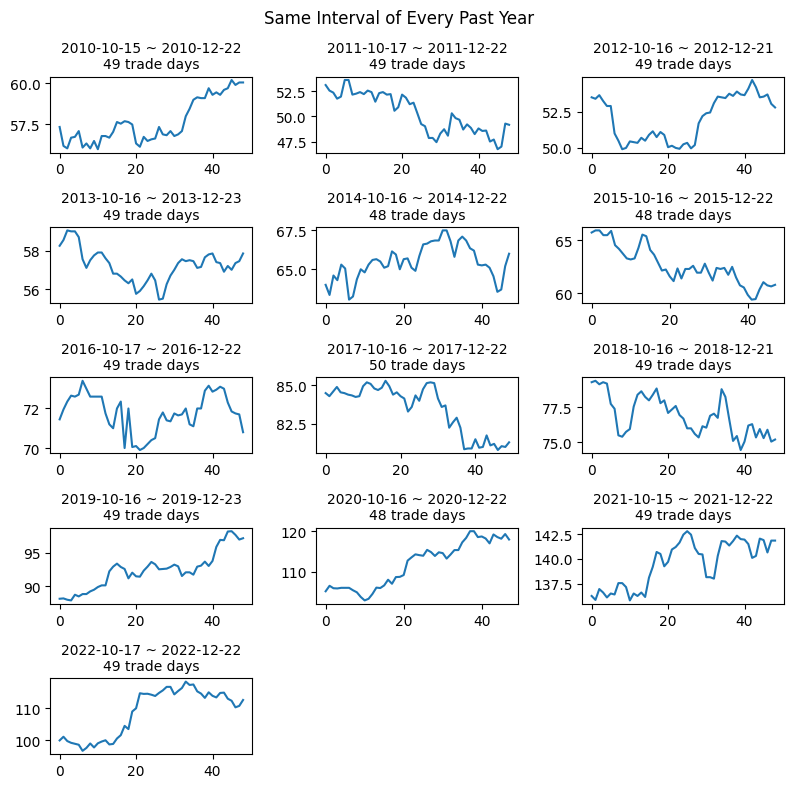

In [7]:
fig = plt.figure(figsize=(8, 8))

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-10-16')
  end_idx = get_nearest_workday_idx(f'{y}-12-22')
  close_price = get_price_interval(beg_idx, end_idx)

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle('Same Interval of Every Past Year')
plt.tight_layout()
plt.show()

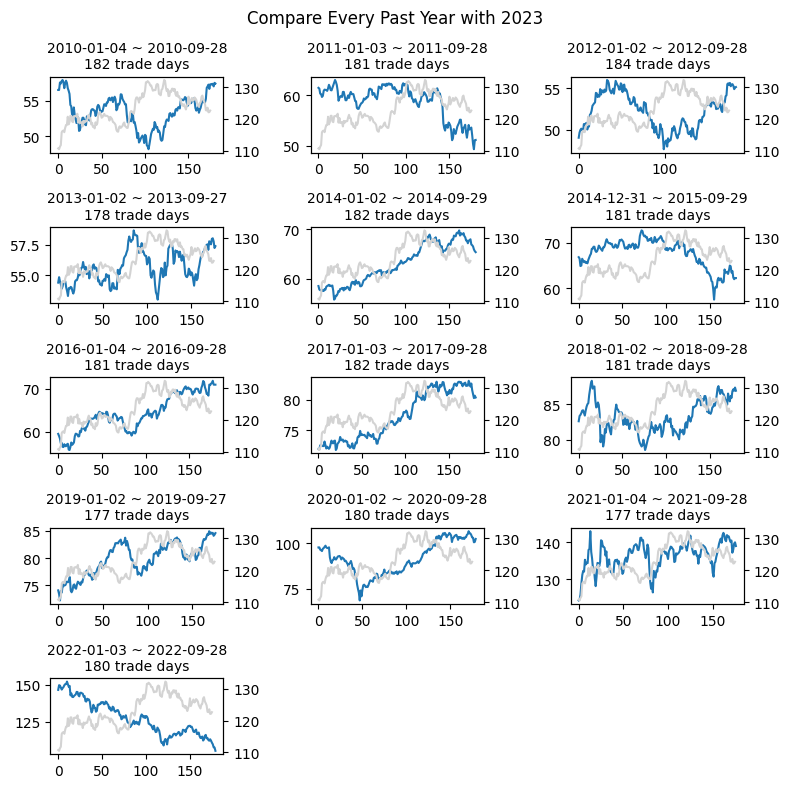

,rho
2017,0.741840
2014,0.727851
2016,0.578945
2019,0.442797
2021,0.404455
2020,0.308456
2013,0.244935
2018,0.096982
2015,-0.180495
2011,-0.237876


In [8]:
fig = plt.figure(figsize=(8, 8))

beg_idx = date_idx.get_loc('2023-01-03')
end_idx = date_idx.get_loc('2023-09-28')
close_price_2023 = get_price_interval(beg_idx, end_idx)

corr_list = pd.Series()

for y in range(2010, 2023):
  beg_idx = get_nearest_workday_idx(f'{y}-01-02')
  end_idx = get_nearest_workday_idx(f'{y}-09-28')
  close_price = get_price_interval(beg_idx, end_idx)

  min_len = min(close_price.shape[0], close_price_2023.shape[0])
  corr = np.corrcoef(close_price[:min_len], close_price_2023[:min_len])[0][1]
  corr_list[y] = corr

  plt.subplot(5, 3, y - 2009)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)
  plt.twinx()
  plt.plot(close_price_2023, 'lightgray')

plt.suptitle(f'Compare Every Past Year with 2023')
plt.tight_layout()
plt.show()

rho = corr_list.sort_values(ascending=False)
pd.DataFrame({ 'rho': rho })

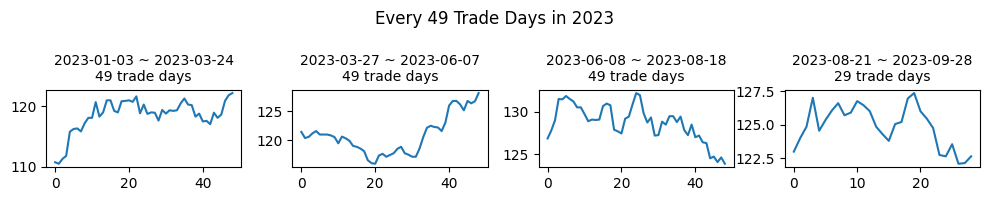

In [9]:
fig = plt.figure(figsize=(10, 2))

n = 49
interval = date[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]
for i, split in enumerate(splits):
  beg_idx = split[0:1].index[0]
  end_idx = split[-1:].index[0]
  close_price = get_price_interval(beg_idx, end_idx)

  plt.subplot(1, 4, i + 1)
  set_title(beg_idx, end_idx)
  plt.plot(close_price)

plt.suptitle(f'Every {n} Trade Days in 2023')
plt.tight_layout()
plt.show()

## Strategy
### Construction

In [10]:
# upper-bound strategy
def get_best_actions(prices: np.ndarray) -> list:
  n = prices.shape[0]
  cash = np.zeros(n)
  stocks = np.zeros(n)
  action_logs = np.zeros((2, n))

  cash[0] = 1000
  stocks[0] = cash[0] / prices[0]
  action_logs[1][0] = 1

  for i in range(1, n):
    new_cash = stocks[i - 1] * prices[i]
    new_stock = cash[i - 1] / prices[i]

    if cash[i - 1] >= new_cash:
      cash[i] = cash[i - 1]
      action_logs[0][i] = 0
    else:
      cash[i] = new_cash
      action_logs[0][i] = -1
    if stocks[i - 1] >= new_stock:
      stocks[i] = stocks[i - 1]
      action_logs[1][i] = 0
    else:
      stocks[i] = new_stock
      action_logs[1][i] = 1

  idx = 0
  actions = []

  for i in range(n - 1, -1, -1):
    if action_logs[idx][i] == 0:
      actions.append(0)
    else:
      actions.append(action_logs[idx][i])
      idx = 1 - idx

  return actions[::-1]

In [11]:
def get_actions_by_strategy(prices: np.ndarray, strategy: Callable) -> list:
	actions = []

	for i in range(prices.shape[0]):
		past_prices = prices[0:i]
		curr_price = prices[i]
		actions.append(strategy(past_prices, curr_price))

	return actions

In [12]:
def rsi_strategy(
  past_prices: np.ndarray, curr_price: np.float64,
  fast_ws: int, slow_ws: int
) -> int:
  if past_prices.shape[0] < slow_ws:
    return 0

  prices = np.append(past_prices, curr_price)
  fast_rsi = talib.RSI(prices, timeperiod=fast_ws)
  slow_rsi = talib.RSI(prices, timeperiod=slow_ws)

  if fast_rsi[-1] > slow_rsi[-1] and fast_rsi[-2] <= slow_rsi[-2]:
    return 1
  if fast_rsi[-1] < slow_rsi[-1] and fast_rsi[-2] >= slow_rsi[-2]:
    return -1

  return 0

In [13]:
def rsi_inv_strategy(
  past_prices: np.ndarray, curr_price: np.float64,
  fast_ws: int, slow_ws: int
) -> int:
  if past_prices.shape[0] < slow_ws:
    return 0

  prices = np.append(past_prices, curr_price)
  fast_rsi = talib.RSI(prices, timeperiod=fast_ws)
  slow_rsi = talib.RSI(prices, timeperiod=slow_ws)

  if fast_rsi[-1] < slow_rsi[-1] and fast_rsi[-2] >= slow_rsi[-2]:
    return 1
  if fast_rsi[-1] > slow_rsi[-1] and fast_rsi[-2] <= slow_rsi[-2]:
    return -1

  return 0

In [14]:
def macd_strategy(
  past_prices: np.ndarray, curr_price: np.float64,
  fastperiod: int, slowperiod: int, signalperiod: int
) -> int:
  if past_prices.shape[0] < slowperiod:
    return 0

  prices = np.append(past_prices, curr_price)
  macd, signal, _ = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  if signal[-1] > macd[-1] and signal[-2] <= macd[-2]:
    return 1
  if signal[-1] < macd[-1] and signal[-2] >= macd[-2]:
    return -1

  return 0

In [15]:
def macd_inv_strategy(
  past_prices: np.ndarray, curr_price: np.float64,
  fastperiod: int, slowperiod: int, signalperiod: int
) -> int:
  if past_prices.shape[0] < slowperiod:
    return 0

  prices = np.append(past_prices, curr_price)
  macd, signal, _ = talib.MACD(prices, fastperiod, slowperiod, signalperiod)

  if signal[-1] < macd[-1] and signal[-2] >= macd[-2]:
    return 1
  if signal[-1] > macd[-1] and signal[-2] <= macd[-2]:
    return -1

  return 0

### Fitting

In [16]:
def calculate_return_rate(prices: np.ndarray, actions: list) -> float:
	capital = 1000
	stock_holding = 0

	for i, action in enumerate(actions):
		curr_price = prices[i]
		if action == 1 and capital > 0:
			stock_holding = capital / curr_price
			capital = 0
		elif action == -1 and stock_holding > 0:
			capital = stock_holding * curr_price
			stock_holding = 0

	final = capital + stock_holding * curr_price
	return (final - 1000) / 1000

In [17]:
def run_back_test(
  exp_interval: np.ndarray,
  strategy: Callable, args: tuple
) -> float:
  actions = []

  for i in range(exp_interval.shape[0]):
    past_prices = exp_interval[:i]
    curr_price = exp_interval[i]
    action = strategy(past_prices, curr_price, *args)
    actions.append(action)

  return calculate_return_rate(exp_interval, actions)

#### Specify Experiment Interval

In [18]:
exp_interval = date[date.str.startswith('2017-')]
beg_idx = date_idx.get_loc(exp_interval.iat[0])
end_idx = date_idx.get_loc(exp_interval.iat[-1])
exp_interval = get_price_interval(beg_idx, end_idx)
n = 49
exp_splits = [exp_interval[i:i+n] for i in range(0, exp_interval.shape[0], n)]
split_num = len(exp_splits)

#### RSI Strategy

In [19]:
max_rr = 0
best_fast_ws = None
best_slow_ws = None

for fast_ws in range(2, 21):
  for slow_ws in range(fast_ws + 1, 41):
    avg_rr = 0

    for split in exp_splits:
      avg_rr += run_back_test(split, rsi_strategy, (fast_ws, slow_ws))
    avg_rr /= split_num

    if avg_rr > max_rr:
      max_rr = avg_rr
      best_fast_ws = fast_ws
      best_slow_ws = slow_ws

print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
print(f'- fast_ws: {best_fast_ws}')
print(f'- slow_ws: {best_slow_ws}')

Maximized Average Return Rate: 2.19%
Best Params:
- fast_ws: 2
- slow_ws: 5


In [20]:
max_rr = 0
best_fast_ws_inv = None
best_slow_ws_inv = None

for fast_ws in range(2, 21):
  for slow_ws in range(fast_ws + 1, 41):
    avg_rr = 0

    for split in exp_splits:
      avg_rr += run_back_test(split, rsi_inv_strategy, (fast_ws, slow_ws))
    avg_rr /= split_num

    if avg_rr > max_rr:
      max_rr = avg_rr
      best_fast_ws_inv = fast_ws
      best_slow_ws_inv = slow_ws

print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
print(f'- fast_ws_inv: {best_fast_ws_inv}')
print(f'- slow_ws_inv: {best_slow_ws_inv}')

Maximized Average Return Rate: 1.88%
Best Params:
- fast_ws_inv: 4
- slow_ws_inv: 11


#### MACD Strategy

In [21]:
max_rr = 0
best_fastperiod = None
best_slowperiod = None
best_signalperiod = None

for signalperiod in range(1, 21):
  for fastperiod in range(signalperiod + 1, 31):
    for slowperiod in range(fastperiod + 1, 41):
      avg_rr = 0
      for split in exp_splits:
        avg_rr += run_back_test(exp_interval, macd_strategy, (fastperiod, slowperiod, signalperiod))
      avg_rr /= split_num

      if avg_rr > max_rr:
        max_rr = avg_rr
        best_fastperiod = fastperiod
        best_slowperiod = slowperiod
        best_signalperiod = signalperiod

print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
print(f'- fastperiod: {best_fastperiod}')
print(f'- slowperiod: {best_slowperiod}')
print(f'- signalperiod: {best_signalperiod}')

Maximized Average Return Rate: 11.08%
Best Params:
- fastperiod: 3
- slowperiod: 13
- signalperiod: 2


In [26]:
max_rr = 0
best_fastperiod_inv = None
best_slowperiod_inv = None
best_signalperiod_inv = None

for signalperiod in range(1, 21):
  for fastperiod in range(signalperiod + 1, 31):
    for slowperiod in range(fastperiod + 1, 41):
      avg_rr = 0
      for split in exp_splits:
        avg_rr += run_back_test(exp_interval, macd_inv_strategy, (fastperiod, slowperiod, signalperiod))
      avg_rr /= split_num

      if avg_rr > max_rr:
        max_rr = avg_rr
        best_fastperiod_inv = fastperiod
        best_slowperiod_inv = slowperiod
        best_signalperiod_inv = signalperiod

print(f'Maximized Average Return Rate: {max_rr * 100:.2f}%')
print('Best Params:')
print(f'- fastperiod_inv: {best_fastperiod_inv}')
print(f'- slowperiod_inv: {best_slowperiod_inv}')
print(f'- signalperiod_inv: {best_signalperiod_inv}')

Maximized Average Return Rate: 12.43%
Best Params:
- fastperiod_inv: 6
- slowperiod_inv: 12
- signalperiod_inv: 4


### Testing

In [27]:
fitted_rsi_strategy = partial(rsi_strategy, fast_ws=best_fast_ws, slow_ws=best_slow_ws)
fitted_macd_strategy = partial(macd_strategy, fastperiod=best_fastperiod, slowperiod=best_slowperiod, signalperiod=best_signalperiod)
fitted_rsi_inv_strategy = partial(rsi_inv_strategy, fast_ws=best_fast_ws_inv, slow_ws=best_slow_ws_inv)
fitted_macd_inv_strategy = partial(macd_strategy, fastperiod=best_fastperiod_inv, slowperiod=best_slowperiod_inv, signalperiod=best_signalperiod_inv)

,0,1,2,3,Total,Average
RSI,-1.54%,5.13%,-4.61%,-0.93%,-1.96%,-0.78%
RSI_inv,3.57%,1.47%,-2.69%,-2.66%,-0.31%,-0.12%
MACD,-2.43%,1.52%,-0.66%,-1.50%,-3.07%,-1.23%
MACD_inv,0.55%,3.58%,-1.38%,-2.23%,0.51%,0.21%
Baseline,4.60%,6.92%,-2.94%,-1.14%,7.44%,2.98%
OPT,27.79%,17.42%,15.10%,10.16%,70.47%,28.19%


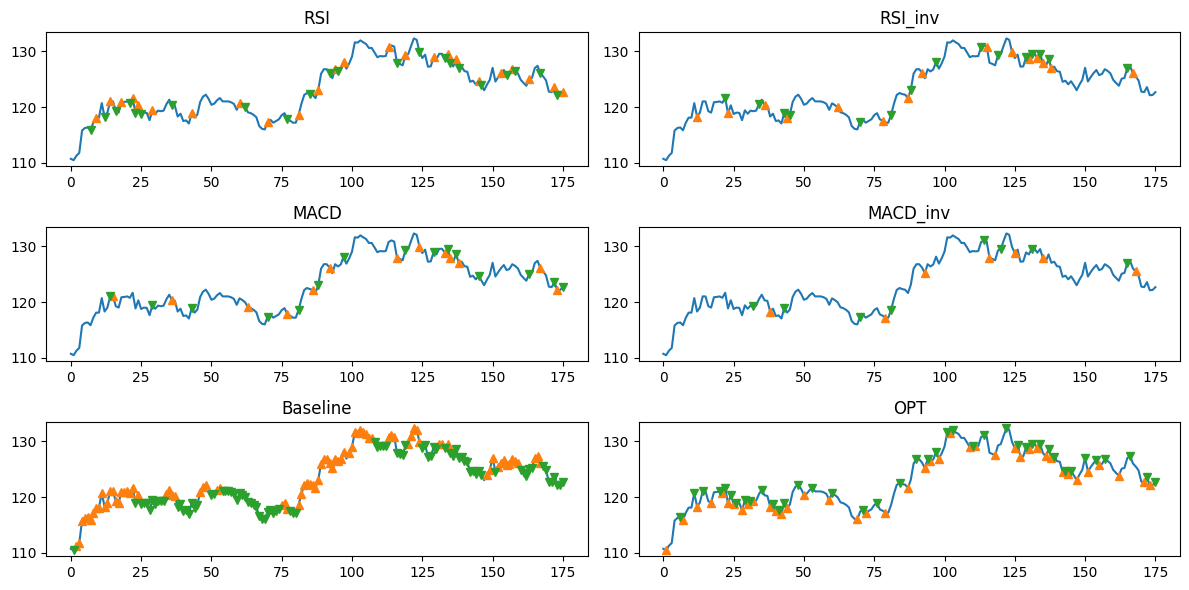

In [30]:
n = 49
interval = adj_close[date.str.startswith('2023-')]
splits = [interval[i:i+n] for i in range(0, interval.shape[0], n)]

strategy_names = [
  'RSI',
  'RSI_inv',
  'MACD',
  'MACD_inv',
  'Baseline',
  'OPT',
]
strategies = [
  fitted_rsi_strategy,
  fitted_rsi_inv_strategy,
  fitted_macd_strategy,
  fitted_macd_inv_strategy,
  baseline_strategy,
]
strategy_num = len(strategy_names)

action_list = [[] for _ in range(strategy_num)]
rr_list = [[] for _ in range(strategy_num)]

for split in splits:
  prices = split.values
  for i, strategy in enumerate(strategies):
    actions = get_actions_by_strategy(prices, strategy)
    rr = calculate_return_rate(prices, actions)
    action_list[i] += actions
    rr_list[i].append(rr)

  best_actions = get_best_actions(prices)
  best_rr = calculate_return_rate(prices, best_actions)
  action_list[-1] += best_actions
  rr_list[-1].append(best_rr)

res = pd.DataFrame({ name: rr for name, rr in zip(strategy_names, rr_list) })
res = res.transpose() * 100
res['Total'] = res.sum(axis=1)
res['Average'] = res.mean(axis=1)

with pd.option_context('display.float_format', '{:.2f}%'.format):
  display(res)

fig = plt.figure(figsize=(12, 6))

for i, name in enumerate(strategy_names):
  plt.subplot(3, 2, i + 1)
  plt.title(name)
  plt.plot(interval.values)
  plot_actions(interval.values, action_list[i])

plt.tight_layout()
plt.show()